In [343]:
# Step 1: Generate Shapes Dataset (Ensures COCO Format)
import subprocess
import os

# Define dataset path
dataset_path = "./shapes_dataset"

# Set dynamic parameters
num_images = 5  # Change this dynamically if needed
image_width = 128  # Change this dynamically if needed
image_height = 128  # Change this dynamically if needed

# Run the dataset generation script inside Jupyter
command = [
    "python", "shapes/run.py",
    "--save_dir", dataset_path,
    "--num_images", str(num_images),
    "--image_size", str(image_width), str(image_height),  # ✅ Explicitly setting image size dynamically
    "--task_type", "segmentation"
]

# Execute the command
result = subprocess.run(command, capture_output=True, text=True)
print(result.stdout)  # Print output for debugging

# Check if dataset is created
if not os.path.exists(f"{dataset_path}/annotations/coco_annotations.json"):
    print("❌ ERROR: Dataset not generated correctly! Check run.py.")
else:
    print(f"✅ Shapes dataset successfully generated with {num_images} images of size {image_width}x{image_height}!")

✅ Dataset and COCO annotations saved to ./shapes_dataset

✅ Shapes dataset successfully generated with 5 images of size 128x128!


In [345]:
#Step 2: Load and Verify COCO Annotations
import json

# Define the correct path for the COCO annotations file
OUTPUT_ANNOTATION_FILE = "./shapes_dataset/annotations/coco_annotations.json"

# Verify COCO Annotations
try:
    with open(OUTPUT_ANNOTATION_FILE, "r") as f:
        coco_data = json.load(f)

    # Show structure
    print("✅ COCO Annotations Loaded Successfully!")
    print(json.dumps(coco_data, indent=4)[:1000])  # Print first 1000 characters

except FileNotFoundError:
    print(f"❌ ERROR: The file {OUTPUT_ANNOTATION_FILE} was not found. Make sure it was generated correctly!")

✅ COCO Annotations Loaded Successfully!
{
    "images": [
        {
            "id": 0,
            "width": 128,
            "height": 128,
            "file_name": "shapes_0.png"
        },
        {
            "id": 1,
            "width": 128,
            "height": 128,
            "file_name": "shapes_1.png"
        },
        {
            "id": 2,
            "width": 128,
            "height": 128,
            "file_name": "shapes_2.png"
        },
        {
            "id": 3,
            "width": 128,
            "height": 128,
            "file_name": "shapes_3.png"
        },
        {
            "id": 4,
            "width": 128,
            "height": 128,
            "file_name": "shapes_4.png"
        }
    ],
    "annotations": [
        {
            "id": 1,
            "image_id": 0,
            "category_id": 2,
            "bbox": [
                94,
                84,
                4,
                4
            ],
            "segmentation": [],
      

✅ Checkpoint already exists at: /Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth
✅ Loaded COCO annotations from ./shapes_dataset/annotations/coco_annotations.json
🔹 Total Images: 5 | Total Annotations: 8
🔹 Processing shapes_0.png | Size: (99, 98)
🛠 Input Box for SAM: [63 40 69 46]
✅ 3 masks detected.
🛠 Input Box for SAM: [14 19 18 22]
✅ 3 masks detected.


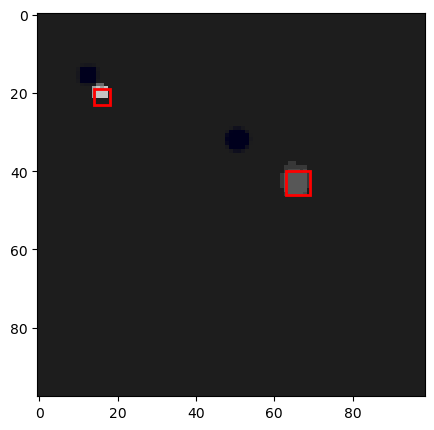

🔹 Processing shapes_1.png | Size: (99, 98)
🛠 Input Box for SAM: [15 73 21 79]
✅ 3 masks detected.


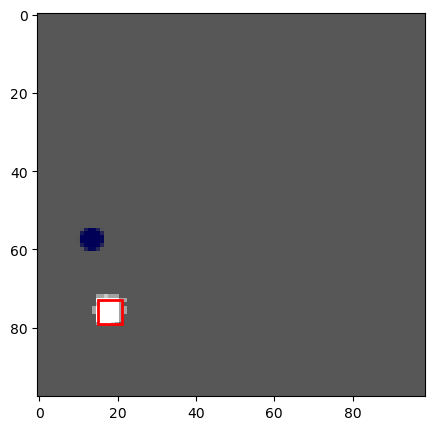

🔹 Processing shapes_2.png | Size: (99, 98)
🛠 Input Box for SAM: [110  67 116  73]
✅ 3 masks detected.
🛠 Input Box for SAM: [119  65 123  68]
✅ 3 masks detected.


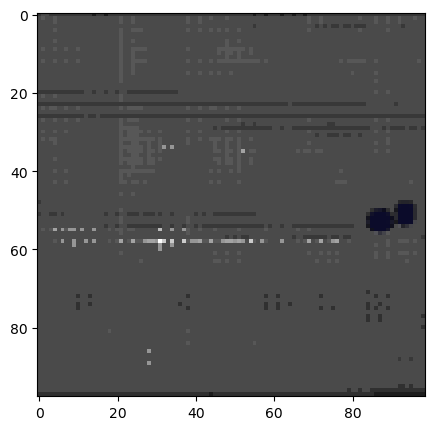

🔹 Processing shapes_3.png | Size: (99, 98)
🛠 Input Box for SAM: [80 26 86 32]
✅ 3 masks detected.


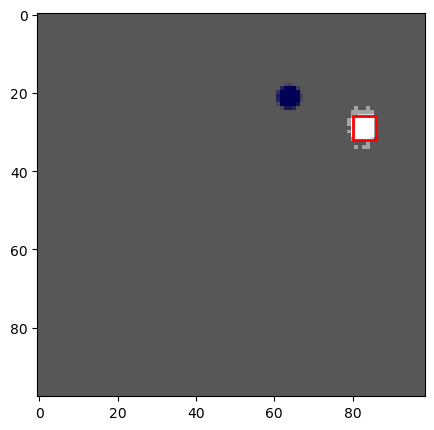

🔹 Processing shapes_4.png | Size: (99, 98)
🛠 Input Box for SAM: [  1 114   7 120]
✅ 3 masks detected.
🛠 Input Box for SAM: [47 40 51 43]
✅ 3 masks detected.


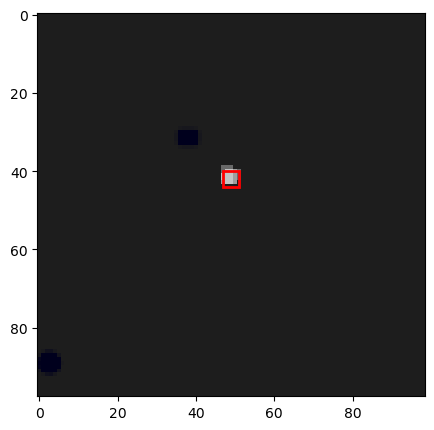


✅ SAM Masks Generated and Saved in COCO Format!
🔹 Images Processed: 5 | Masks Generated: 21 | No Masks: 0


In [331]:
# Step 3: Load SAM Model & Process COCO Annotations with Visualization
import os
import json
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

# ============================
# 🔹 Load SAM Model with Debugging
# ============================

CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
WEIGHTS_DIR = "/Users/ma/Documents/samThesis/segment-anything/weights"
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, "sam_vit_h_4b8939.pth")

# Create directory if needed
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Download checkpoint if not exists
if not os.path.isfile(CHECKPOINT_PATH):
    os.system(f"curl -o {CHECKPOINT_PATH} {CHECKPOINT_URL}")
    print(f"✅ Downloaded SAM checkpoint to: {CHECKPOINT_PATH}")
else:
    print(f"✅ Checkpoint already exists at: {CHECKPOINT_PATH}")

# Load SAM model
sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
predictor = SamPredictor(sam)

# ============================
# 🔹 Load COCO Annotations with Debugging
# ============================

DATASET_PATH = "./shapes_dataset"
ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations.json")
OUTPUT_ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations_with_masks.json")

# Check if annotation file exists
if not os.path.exists(ANNOTATION_FILE):
    print(f"❌ ERROR: COCO annotation file not found: {ANNOTATION_FILE}")
    raise FileNotFoundError(f"COCO annotation file {ANNOTATION_FILE} does not exist!")

# Load COCO JSON
with open(ANNOTATION_FILE, "r") as f:
    coco_data = json.load(f)

print(f"✅ Loaded COCO annotations from {ANNOTATION_FILE}")
print(f"🔹 Total Images: {len(coco_data['images'])} | Total Annotations: {len(coco_data['annotations'])}")

# Debug: Check if images exist
if len(coco_data["images"]) == 0:
    print("⚠️ WARNING: No images found in COCO annotations! Check dataset generation.")
    raise ValueError("COCO dataset has no images!")

# Debug: Check if annotations exist
if len(coco_data["annotations"]) == 0:
    print("⚠️ WARNING: No annotations found in COCO annotations! Expected bounding boxes.")
    raise ValueError("COCO dataset has no annotations!")

# ============================
# 🔹 Run SAM on Each Image & Generate Masks (with Normalization & Visualization)
# ============================

new_annotations = []
masks_generated = 0
no_masks_found = 0

for img_info in coco_data["images"]:
    img_path = os.path.join(DATASET_PATH, "images", img_info["file_name"])

    # Check if image exists
    if not os.path.exists(img_path):
        print(f"⚠️ Skipping: {img_info['file_name']} (File Not Found)")
        continue

    # Load image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image)

    img_width, img_height = image.shape[1], image.shape[0]  # Get actual image size

    print(f"🔹 Processing {img_info['file_name']} | Size: ({img_width}, {img_height})")

    # Get annotations for the current image
    img_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == img_info["id"]]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image)

    for ann in img_annotations:
        bbox = ann["bbox"]
        x, y, w, h = map(int, bbox)

        # ✅ Normalize Bounding Box (0-1 scale)
        x_norm = x / img_width
        y_norm = y / img_height
        w_norm = w / img_width
        h_norm = h / img_height

        # ✅ Convert back to absolute pixel values
        x_scaled = int(x_norm * img_width)
        y_scaled = int(y_norm * img_height)
        w_scaled = int(w_norm * img_width)
        h_scaled = int(h_norm * img_height)

        # Adjusted Input Box for SAM
        input_box = np.array([x_scaled, y_scaled, x_scaled + w_scaled, y_scaled + h_scaled])

        print(f"🛠 Input Box for SAM: {input_box}")

        # Run SAM for segmentation mask generation
        sam_masks, _, _ = predictor.predict(box=input_box)

        # Debugging: Check if SAM generated masks
        if len(sam_masks) == 0:
            print(f"⚠️ No masks found for {img_info['file_name']}! Skipping annotation.")
            no_masks_found += 1
            continue
        else:
            print(f"✅ {len(sam_masks)} masks detected.")

        # ✅ Draw Bounding Box
        rect = plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        ax.add_patch(rect)

        # Normalize & Convert Mask to COCO Segmentation Format
        for mask in sam_masks:
            mask_indices = np.argwhere(mask)  # Get mask pixel positions
            mask_indices = mask_indices.astype(np.float32)  # Ensure float precision

            # ✅ Normalize the mask positions relative to the image size
            mask_indices[:, 0] /= img_height  # Normalize Y
            mask_indices[:, 1] /= img_width   # Normalize X

            # Scale back to pixel values for COCO format
            mask_indices[:, 0] *= img_height
            mask_indices[:, 1] *= img_width

            segmentation = mask_indices.flatten().tolist()

            # Draw Mask (Overlay)
            ax.imshow(mask, alpha=0.3, cmap="gray")

            # Save updated annotation with segmentation mask
            if segmentation:
                new_annotations.append({
                    "id": len(new_annotations) + 1,
                    "image_id": img_info["id"],
                    "category_id": ann["category_id"],
                    "segmentation": [segmentation],  # List of coordinates
                    "area": int(np.sum(mask)),  # Mask area
                    "bbox": ann["bbox"],  # Keep original bbox
                    "iscrowd": 0
                })
                masks_generated += 1

    plt.show()  # Show visualization per image

# ============================
# 🔹 Save Updated COCO Annotations
# ============================

# Update annotations in COCO JSON
coco_data["annotations"] = new_annotations

# Save updated COCO JSON
with open(OUTPUT_ANNOTATION_FILE, "w") as f:
    json.dump(coco_data, f, indent=4)

# Debugging Summary
print("\n✅ SAM Masks Generated and Saved in COCO Format!")
print(f"🔹 Images Processed: {len(coco_data['images'])} | Masks Generated: {masks_generated} | No Masks: {no_masks_found}")

# Final validation check
if len(new_annotations) == 0:
    print("❌ ERROR: No segmentation data generated! Check SAM mask outputs.")

In [349]:
# Step 4: Verify Updated COCO Annotations
# Load updated COCO annotations
with open(OUTPUT_ANNOTATION_FILE, "r") as f:
    updated_coco_data = json.load(f)

# Check if segmentation is now included
sample_ann = next((ann for ann in updated_coco_data["annotations"] if "segmentation" in ann), None)

if sample_ann:
    print("✅ Segmentation Data Found in COCO Format!")
    print(json.dumps(sample_ann, indent=4))
else:
    print("❌ ERROR: No segmentation data found. Ensure SAM generated masks correctly!")


✅ Segmentation Data Found in COCO Format!
{
    "id": 1,
    "image_id": 0,
    "category_id": 2,
    "segmentation": [
        [
            0.8571428571428571,
            0.9595959595959596,
            0.8571428571428571,
            0.9696969696969697,
            0.8571428571428571,
            0.9797979797979798,
            0.8673469387755102,
            0.9595959595959596,
            0.8673469387755102,
            0.9696969696969697,
            0.8673469387755102,
            0.9797979797979798,
            0.8775510204081632,
            0.9494949494949495,
            0.8775510204081632,
            0.9595959595959596,
            0.8775510204081632,
            0.9696969696969697,
            0.8775510204081632,
            0.9797979797979798,
            0.8775510204081632,
            0.98989898989899,
            0.8877551020408163,
            0.9494949494949495,
            0.8877551020408163,
            0.9595959595959596,
            0.8877551020408163,
        

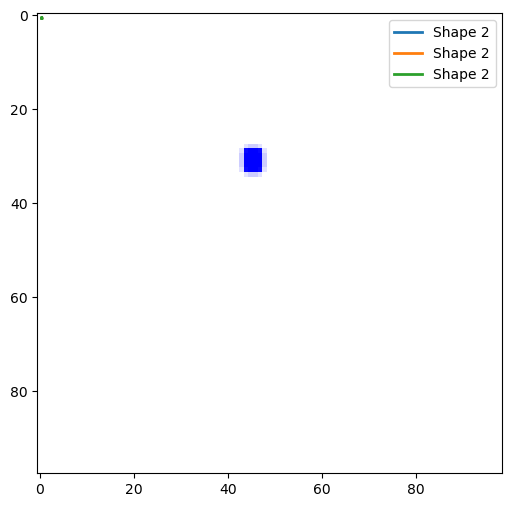

In [361]:
# Step 5: Visualize the Segmentation Masks
import matplotlib.pyplot as plt

# Pick a random image
image_id = np.random.choice(len(updated_coco_data["images"]))
image_info = updated_coco_data["images"][image_id]
image_path = os.path.join(image_dir, image_info["file_name"])

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Load segmentation masks
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image)

for ann in updated_coco_data["annotations"]:
    if ann["image_id"] == image_info["id"]:
        for seg in ann["segmentation"]:
            poly = np.array(seg).reshape(-1, 2)
            ax.plot(poly[:, 0], poly[:, 1], linewidth=2, label=f"Shape {ann['category_id']}")

ax.legend()
plt.show()

✅ Loaded COCO annotations from ./shapes_dataset/annotations/coco_annotations.json
🔹 Total Images: 5 | Total Annotations: 8

📌 Processing shapes_0.png | Size: 99x98
🛠 Input Box for SAM: [34 33 40 39]


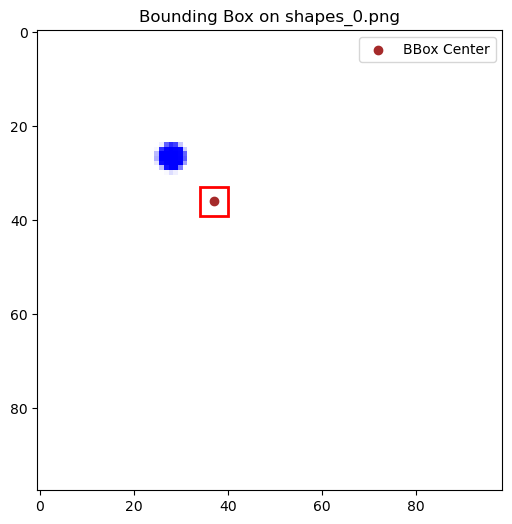

📍 BBox Center (Pixel): (37, 36)
📌 Mask Center (Pixel): [35.79310345 36.48275862]


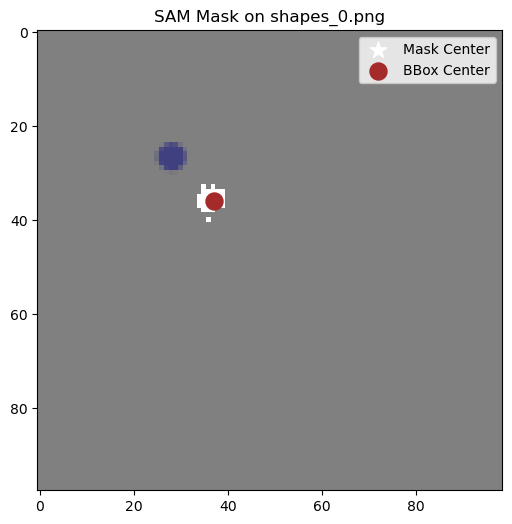

📍 BBox Center (Pixel): (37, 36)
📌 Mask Center (Pixel): [36.23809524 36.78571429]


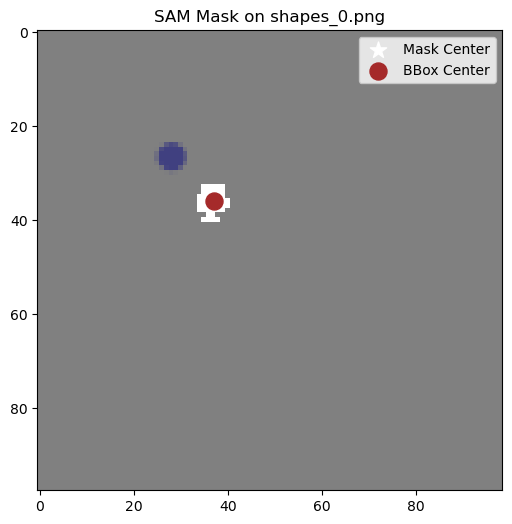

📍 BBox Center (Pixel): (37, 36)
📌 Mask Center (Pixel): [35.66071429 36.71428571]


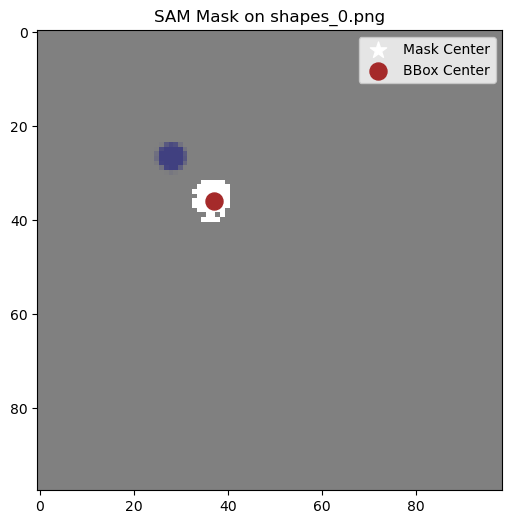


📌 Processing shapes_1.png | Size: 99x98
🛠 Input Box for SAM: [37  3 41  7]


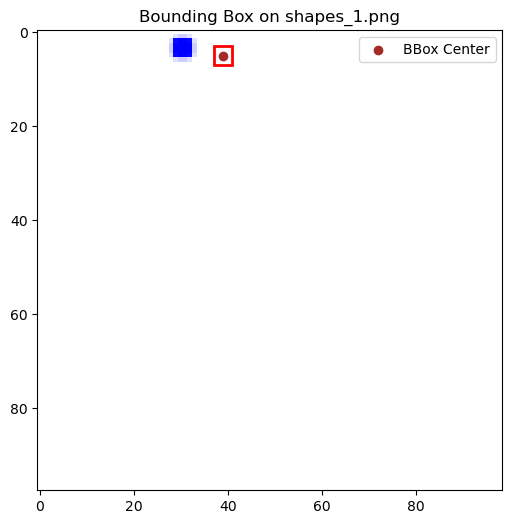

📍 BBox Center (Pixel): (39, 5)
📌 Mask Center (Pixel): [ 4.6 38.6]


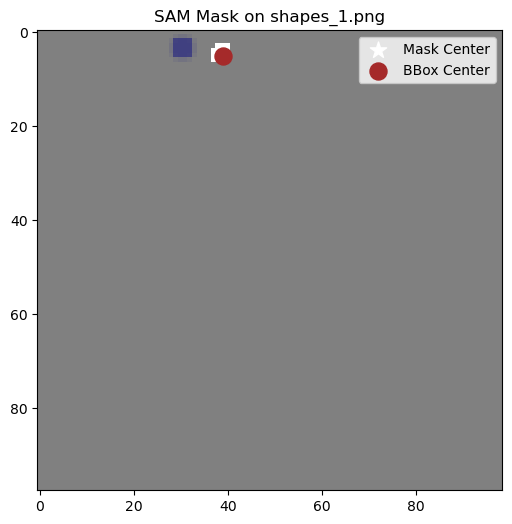

📍 BBox Center (Pixel): (39, 5)
📌 Mask Center (Pixel): [ 4.57894737 38.10526316]


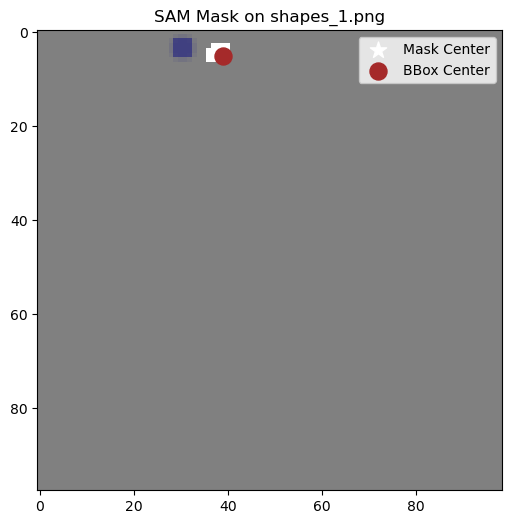

📍 BBox Center (Pixel): (39, 5)
📌 Mask Center (Pixel): [ 4.14814815 38.18518519]


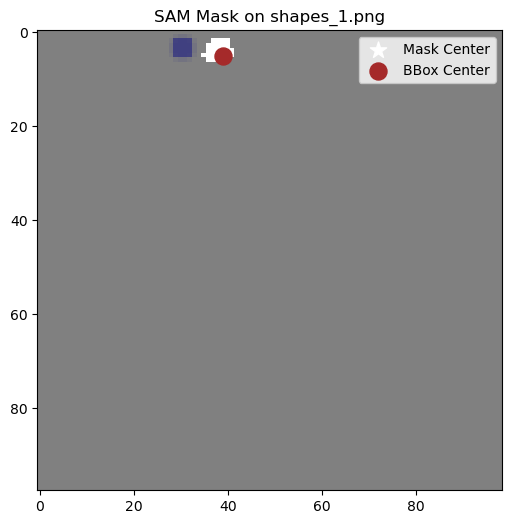


📌 Processing shapes_2.png | Size: 99x98
🛠 Input Box for SAM: [10 45 14 49]


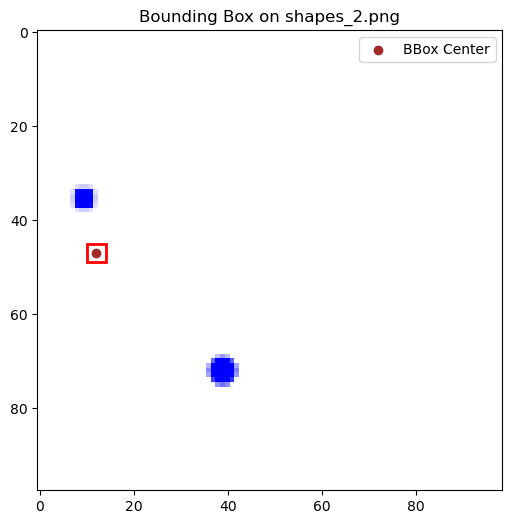

📍 BBox Center (Pixel): (12, 47)
📌 Mask Center (Pixel): [46.5 11. ]


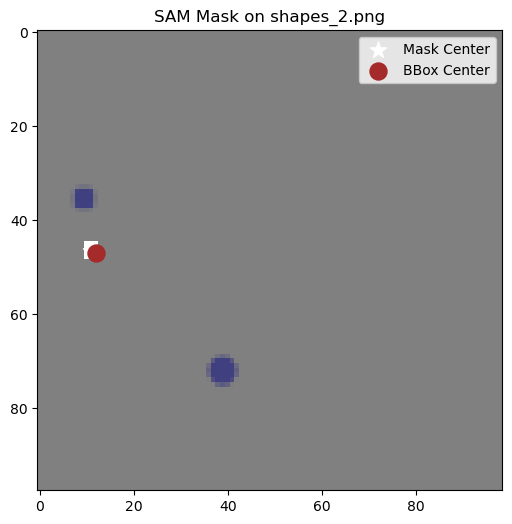

📍 BBox Center (Pixel): (12, 47)
📌 Mask Center (Pixel): [46.80952381 11.85714286]


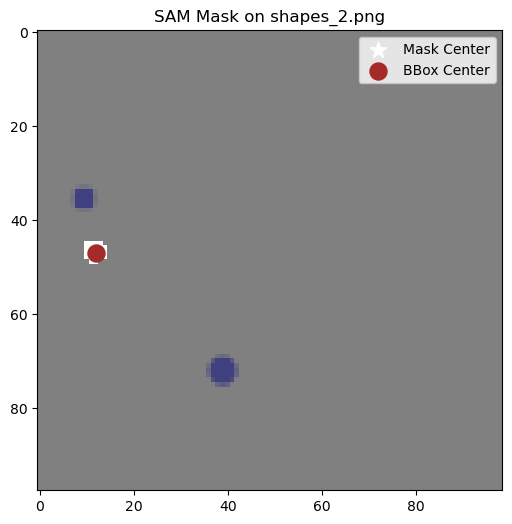

📍 BBox Center (Pixel): (12, 47)
📌 Mask Center (Pixel): [46.40740741 11.92592593]


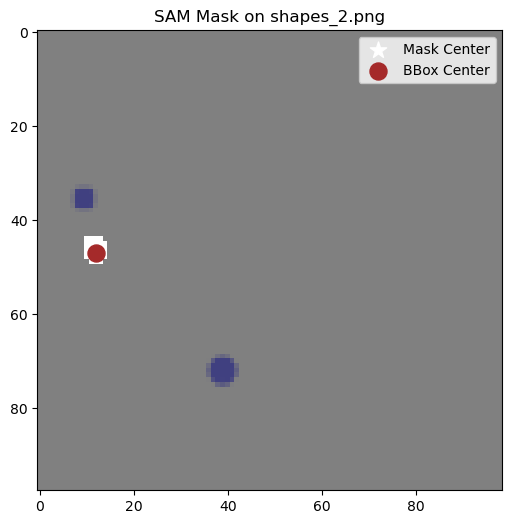

🛠 Input Box for SAM: [48 92 54 98]


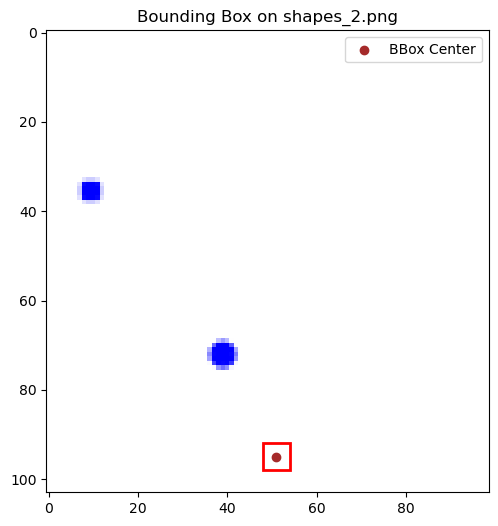

📍 BBox Center (Pixel): (51, 95)
📌 Mask Center (Pixel): [95.2 50.2]


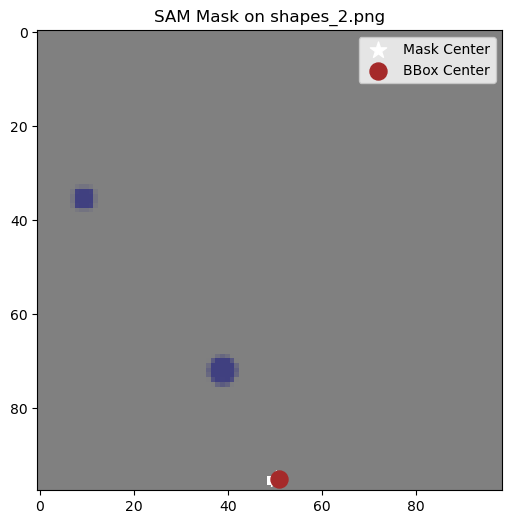

📍 BBox Center (Pixel): (51, 95)
📌 Mask Center (Pixel): [94.88235294 51.29411765]


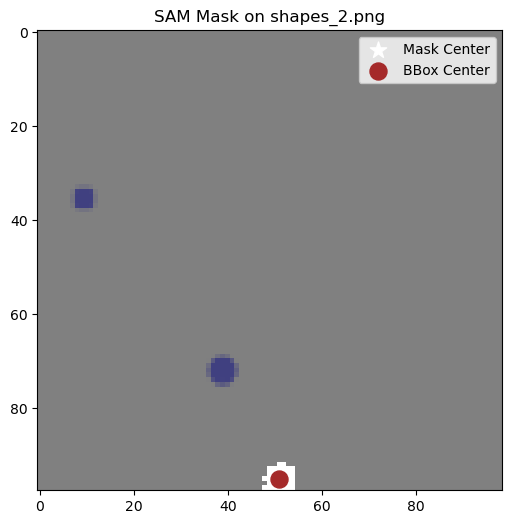

📍 BBox Center (Pixel): (51, 95)
📌 Mask Center (Pixel): [94.55319149 50.74468085]


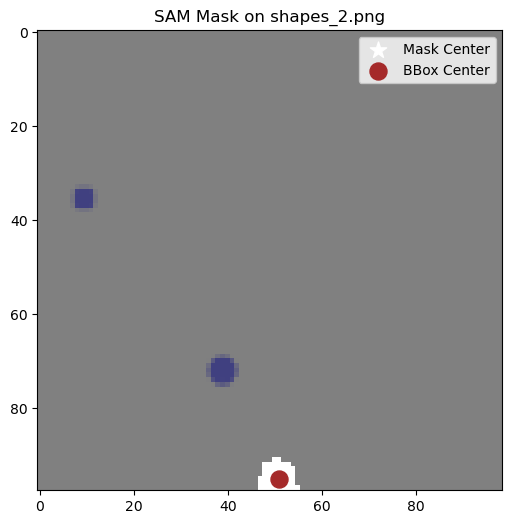


📌 Processing shapes_3.png | Size: 99x98
🛠 Input Box for SAM: [ 93 117  97 121]


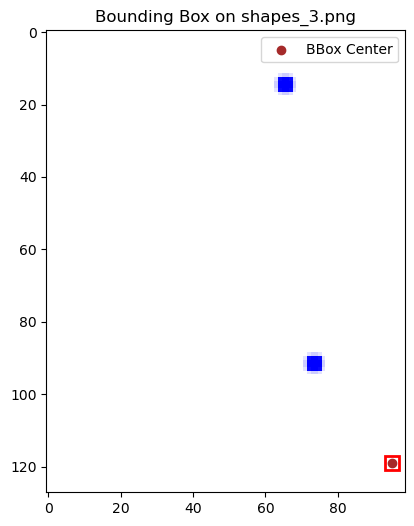

🛠 Input Box for SAM: [82 18 86 22]


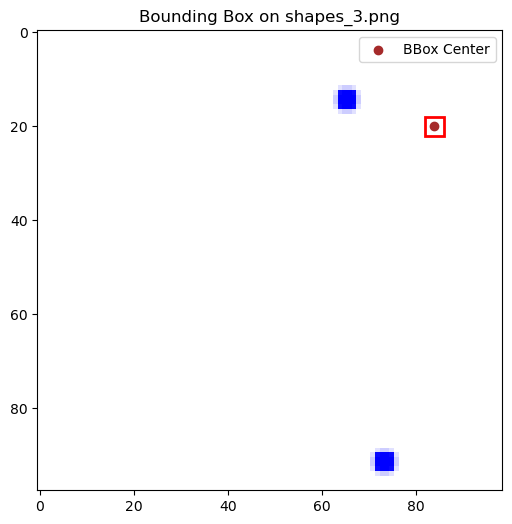

📍 BBox Center (Pixel): (84, 20)
📌 Mask Center (Pixel): [19.54545455 83.81818182]


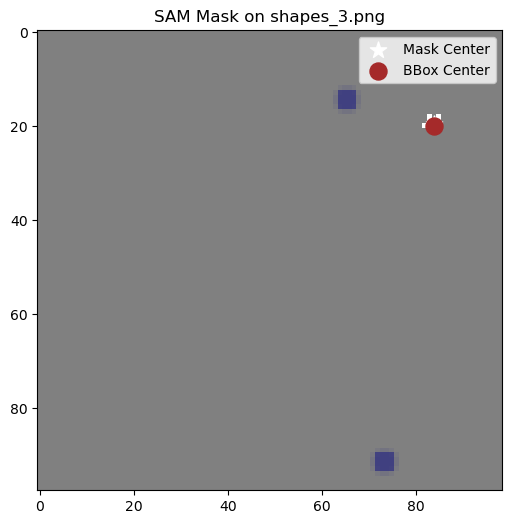

📍 BBox Center (Pixel): (84, 20)
📌 Mask Center (Pixel): [19.75  83.625]


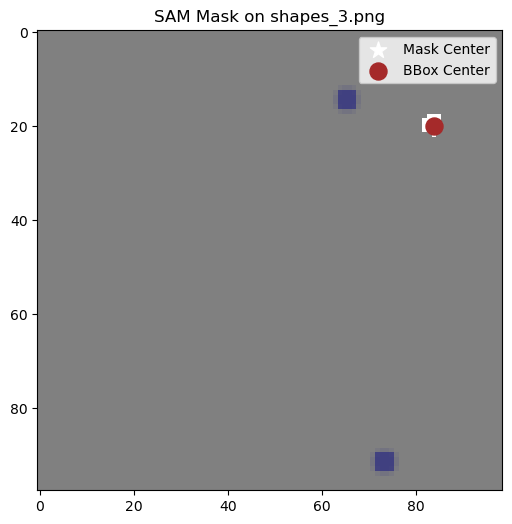

📍 BBox Center (Pixel): (84, 20)
📌 Mask Center (Pixel): [19.85714286 83.33333333]


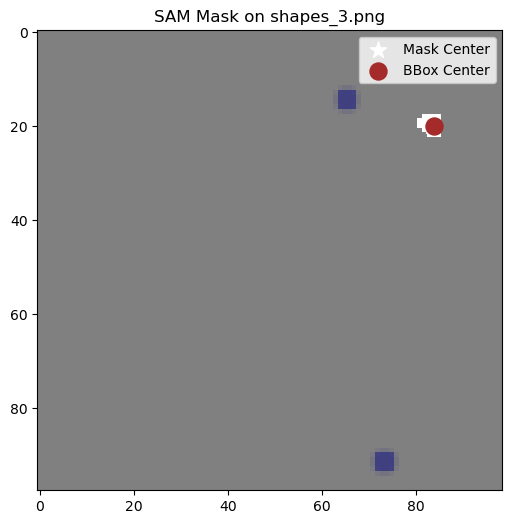


📌 Processing shapes_4.png | Size: 99x98
🛠 Input Box for SAM: [122   6 126  10]


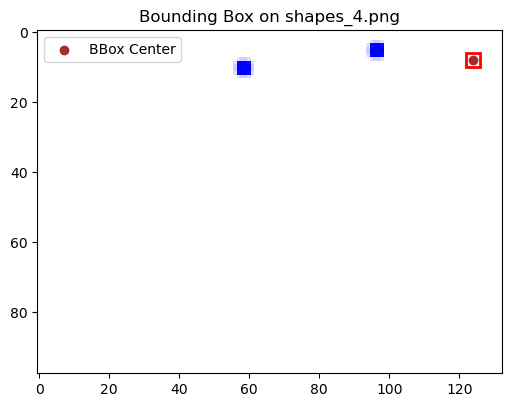

🛠 Input Box for SAM: [74 12 78 16]


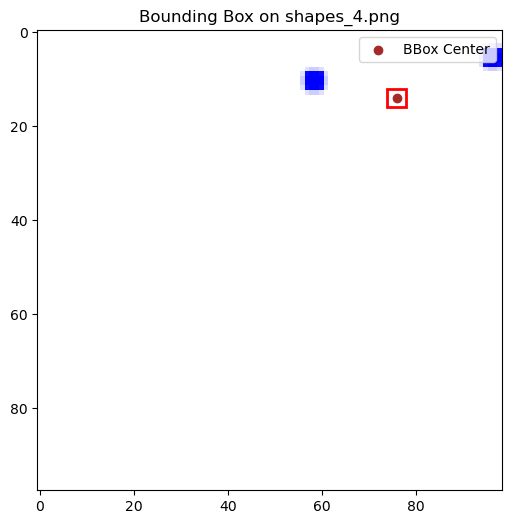

📍 BBox Center (Pixel): (76, 14)
📌 Mask Center (Pixel): [14. 76.]


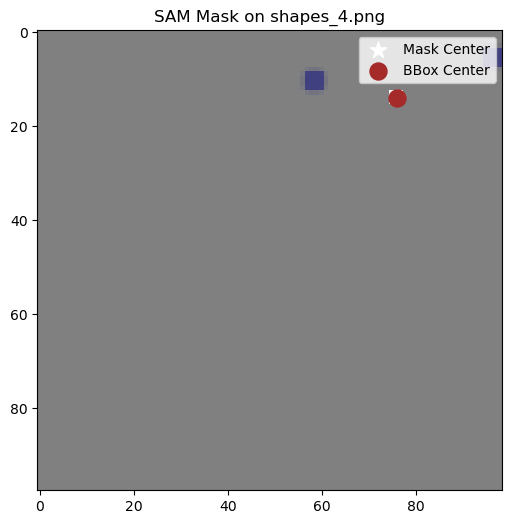

📍 BBox Center (Pixel): (76, 14)
📌 Mask Center (Pixel): [13.88235294 75.70588235]


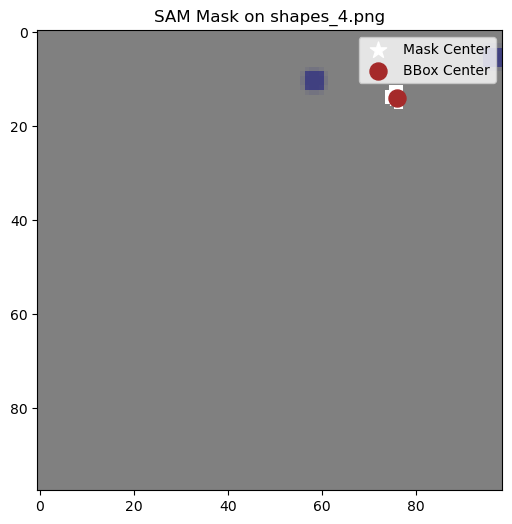

📍 BBox Center (Pixel): (76, 14)
📌 Mask Center (Pixel): [13.5        75.61538462]


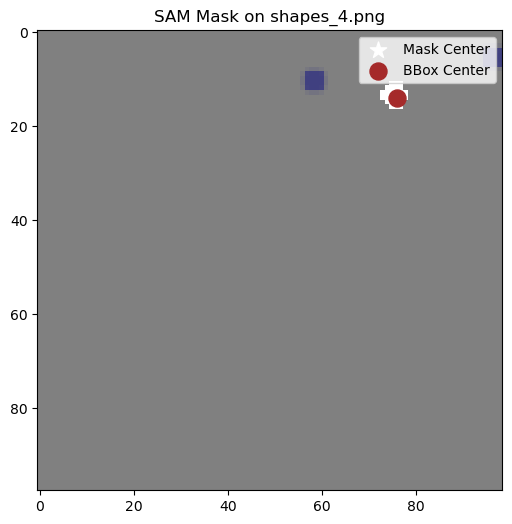


✅ SAM Masks Generated and Saved in COCO Format!
🔹 Images Processed: 5 | Masks Generated: 18


In [298]:
#Another version of Step 3 - Fixing Coordinate Misalignment & Debugging
import os
import json
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

# ============================
# 🔹 Load SAM Model
# ============================
CHECKPOINT_PATH = "/Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth"
sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
predictor = SamPredictor(sam)

# ============================
# 🔹 Load COCO Annotations
# ============================
DATASET_PATH = "./shapes_dataset"
ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations.json")
OUTPUT_ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations_with_masks.json")

with open(ANNOTATION_FILE, "r") as f:
    coco_data = json.load(f)

print(f"✅ Loaded COCO annotations from {ANNOTATION_FILE}")
print(f"🔹 Total Images: {len(coco_data['images'])} | Total Annotations: {len(coco_data['annotations'])}")

# ============================
# 🔹 Process Each Image
# ============================
new_annotations = []

for img_info in coco_data["images"]:
    img_path = os.path.join(DATASET_PATH, "images", img_info["file_name"])

    if not os.path.exists(img_path):
        print(f"⚠️ Skipping missing image: {img_info['file_name']}")
        continue

    # Load image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image)

    height, width = image.shape[:2]  # Get image dimensions
    print(f"\n📌 Processing {img_info['file_name']} | Size: {width}x{height}")

    img_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == img_info["id"]]

    for ann in img_annotations:
        bbox = ann["bbox"]
        x, y, w, h = bbox
        input_box = np.array([x, y, x + w, y + h])

        print(f"🛠 Input Box for SAM: {input_box}")

        # Run SAM
        sam_masks, _, _ = predictor.predict(box=input_box)

        # Visual Debug: Bounding Box
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(image)
        ax.add_patch(plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2))
        ax.set_title(f"Bounding Box on {img_info['file_name']}")
        plt.scatter(x + w // 2, y + h // 2, marker="o", color="brown", label="BBox Center")
        plt.legend()
        plt.show()

        # Debugging: Ensure masks align with bounding box
        for mask in sam_masks:
            mask_indices = np.argwhere(mask)  # Extract nonzero mask indices
            if len(mask_indices) == 0:
                continue

            mask_center = np.mean(mask_indices, axis=0)
            bbox_center = [x + w // 2, y + h // 2]

            print(f"📍 BBox Center (Pixel): {tuple(map(int, bbox_center))}")
            print(f"📌 Mask Center (Pixel): {mask_center}")

            # Normalize mask segmentation coordinates
            segmentation = (mask_indices / [height, width]).flatten().tolist()
            if segmentation:
                new_annotations.append({
                    "id": len(new_annotations) + 1,
                    "image_id": img_info["id"],
                    "category_id": ann["category_id"],
                    "segmentation": [segmentation],  # Normalized segmentation
                    "area": int(np.sum(mask)),
                    "bbox": ann["bbox"],
                    "iscrowd": 0
                })

            # Visual Debug: Mask Overlay
            fig, ax = plt.subplots(figsize=(6, 6))
            ax.imshow(image, alpha=0.5)
            ax.imshow(mask, alpha=0.5, cmap="gray")
            ax.set_title(f"SAM Mask on {img_info['file_name']}")
            plt.scatter(mask_center[1], mask_center[0], marker="*", color="white", s=150, label="Mask Center")
            plt.scatter(bbox_center[0], bbox_center[1], marker="o", color="brown", s=150, label="BBox Center")
            plt.legend()
            plt.show()

# ============================
# 🔹 Save Updated Annotations
# ============================
coco_data["annotations"] = new_annotations
with open(OUTPUT_ANNOTATION_FILE, "w") as f:
    json.dump(coco_data, f, indent=4)

# Final validation
if len(new_annotations) == 0:
    print("❌ ERROR: No segmentation data generated! Check SAM mask outputs.")
else:
    print(f"\n✅ SAM Masks Generated and Saved in COCO Format!")
    print(f"🔹 Images Processed: {len(coco_data['images'])} | Masks Generated: {len(new_annotations)}")

In [ ]:
# Print image details
height, width = image.shape[:2]
print(f"📌 Image: {img_info['file_name']} | Size: {width}x{height}")

# Print bounding box coordinates in both systems
print(f"🟥 Original COCO BBox (Pixel): {bbox}")  
normalized_bbox = [bbox[0] / width, bbox[1] / height, (bbox[0] + bbox[2]) / width, (bbox[1] + bbox[3]) / height]
print(f"📏 Normalized BBox: {normalized_bbox}")

# Generate masks
sam_masks, _, _ = predictor.predict(box=input_box)

# Debugging: Print mask locations
for idx, mask in enumerate(sam_masks):
    mask_indices = np.argwhere(mask)  
    print(f"🔍 Mask {idx} Raw Indices: {mask_indices[:5]}")  # Print first 5 indices

    # Convert to COCO-style segmentation format
    segmentation = (mask_indices / [height, width]).flatten().tolist()
    print(f"📌 Normalized Segmentation (First 10 pts): {segmentation[:10]}")  

In [339]:
for img_info in coco_data["images"]:
    image_path = os.path.join(image_dir, img_info["file_name"])
    image = cv2.imread(image_path)
    height, width = image.shape[:2]
    print(f"📌 Image: {img_info['file_name']} | Size: ({width}, {height})")

📌 Image: shapes_0.png | Size: (99, 98)
📌 Image: shapes_1.png | Size: (99, 98)
📌 Image: shapes_2.png | Size: (99, 98)
📌 Image: shapes_3.png | Size: (99, 98)
📌 Image: shapes_4.png | Size: (99, 98)


In [341]:
for ann in coco_data["annotations"]:
    img_id = ann["image_id"]
    bbox = ann["bbox"]
    x, y, w, h = bbox
    bbox_center = (x + w / 2, y + h / 2)

    if img_id in sam_masks:
        mask_indices = np.argwhere(sam_masks[img_id])
        if len(mask_indices) > 0:
            mask_center = np.mean(mask_indices, axis=0)
        else:
            mask_center = "No mask detected"

        print(f"🟥 COCO BBox: {bbox} → Center: {bbox_center}")
        print(f"📌 SAM Mask Center: {mask_center}")

        # Highlight potential mismatch
        if isinstance(mask_center, np.ndarray) and (
            abs(bbox_center[0] - mask_center[1]) > 5 or abs(bbox_center[1] - mask_center[0]) > 5
        ):
            print("⚠️ Possible Misalignment Detected!")

In [347]:
import os
import json
import cv2
import numpy as np
import torch
from segment_anything import sam_model_registry, SamPredictor

# ============================
# 🔹 Load SAM Model
# ============================
CHECKPOINT_PATH = "/Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth"
sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
predictor = SamPredictor(sam)

# ============================
# 🔹 Load COCO Annotations
# ============================
DATASET_PATH = "./shapes_dataset"
ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations.json")
OUTPUT_ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations_fixed.json")

with open(ANNOTATION_FILE, "r") as f:
    coco_data = json.load(f)

print(f"✅ Loaded COCO annotations from {ANNOTATION_FILE}")
print(f"🔹 Total Images: {len(coco_data['images'])} | Total Annotations: {len(coco_data['annotations'])}")

# ============================
# 🔹 Verify Image Sizes & Normalize Bounding Boxes
# ============================
new_annotations = []
for img_info in coco_data["images"]:
    img_path = os.path.join(DATASET_PATH, "images", img_info["file_name"])

    # ✅ Load Image and Get Dimensions
    if not os.path.exists(img_path):
        print(f"❌ ERROR: Image {img_info['file_name']} not found! Skipping...")
        continue

    image = cv2.imread(img_path)
    height, width = image.shape[:2]
    print(f"\n📌 Processing {img_info['file_name']} | Size: ({width}, {height})")

    # ✅ Get Bounding Box and Check Center Alignment
    img_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == img_info["id"]]
    
    for ann in img_annotations:
        x, y, w, h = ann["bbox"]
        bbox_center = (x + w / 2, y + h / 2)

        # ✅ Convert COCO BBox to SAM Format
        sam_bbox = [x, y, x + w, y + h]
        
        # ✅ Normalize Bounding Box for Debugging
        normalized_bbox = [x / width, y / height, (x + w) / width, (y + h) / height]

        print(f"🟥 COCO BBox (Pixel): {ann['bbox']}")
        print(f"📏 Normalized BBox: {normalized_bbox}")
        print(f"🛠 Input Box for SAM: {sam_bbox}")

        # ✅ Debugging: Run SAM on Each Image
        predictor.set_image(image)
        sam_masks, _, _ = predictor.predict(box=np.array(sam_bbox))

        if len(sam_masks) == 0:
            print(f"⚠️ Warning: No SAM masks found for image ID {img_info['id']}")
            continue
        else:
            print(f"✅ {len(sam_masks)} masks detected.")

        # ✅ Store Normalized Segmentation
        for mask in sam_masks:
            mask_indices = np.argwhere(mask)
            segmentation = (mask_indices / [height, width]).flatten().tolist()
            
            new_annotations.append({
                "id": len(new_annotations) + 1,
                "image_id": img_info["id"],
                "category_id": ann["category_id"],
                "segmentation": [segmentation],
                "area": int(np.sum(mask)),
                "bbox": ann["bbox"],
                "iscrowd": 0
            })

# ============================
# 🔹 Save Fixed COCO Annotations
# ============================
coco_data["annotations"] = new_annotations
with open(OUTPUT_ANNOTATION_FILE, "w") as f:
    json.dump(coco_data, f, indent=4)

print(f"\n✅ Fixed COCO annotations saved to: {OUTPUT_ANNOTATION_FILE}")

✅ Loaded COCO annotations from ./shapes_dataset/annotations/coco_annotations.json
🔹 Total Images: 5 | Total Annotations: 6

📌 Processing shapes_0.png | Size: (99, 98)
🟥 COCO BBox (Pixel): [94, 84, 4, 4]
📏 Normalized BBox: [0.9494949494949495, 0.8571428571428571, 0.98989898989899, 0.8979591836734694]
🛠 Input Box for SAM: [94, 84, 98, 88]
✅ 3 masks detected.
🟥 COCO BBox (Pixel): [77, 72, 4, 4]
📏 Normalized BBox: [0.7777777777777778, 0.7346938775510204, 0.8181818181818182, 0.7755102040816326]
🛠 Input Box for SAM: [77, 72, 81, 76]
✅ 3 masks detected.

📌 Processing shapes_1.png | Size: (99, 98)
🟥 COCO BBox (Pixel): [57, 39, 4, 4]
📏 Normalized BBox: [0.5757575757575758, 0.3979591836734694, 0.6161616161616161, 0.4387755102040816]
🛠 Input Box for SAM: [57, 39, 61, 43]
✅ 3 masks detected.

📌 Processing shapes_2.png | Size: (99, 98)
🟥 COCO BBox (Pixel): [71, 51, 4, 4]
📏 Normalized BBox: [0.7171717171717171, 0.5204081632653061, 0.7575757575757576, 0.5612244897959183]
🛠 Input Box for SAM: [71, 51,